# APD Sector Crime Analysis for Dashboard

This notebook builds on the preprocessed sector-level crime datasets from 02_preprocessing.ipynb. Using visualizations, this notebook explores patterns in Austin crime data to answer key questions and support informed decision-making.

Goals:
- Load the preprocessed crime datasets (CSV + GeoJSON) with standarized APD sector identifiers
- Visualize the spatial distribution of crime incidents
- Examine temporal patterns (time of day, day of week, trends over years) to identify when crime peaks
- Analyze crime types and their distribution across sectors to uncover both common and localized patterns
- Compare sectors to reveal differences in crime volume and type distributions
- Provide actionable insights for dashboard development

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.rcParams["figure.figsize"] = (10, 6) # Set default figure size

%matplotlib inline

## Load preprocessed crime data set

In [2]:
crime_df = pd.read_csv("../data/austin_crime_preprocessed.csv", parse_dates=["occurred_date_time", "report_date_time"])

# check
crime_df.shape
crime_df.head()

,incident_number,highest_offense_description,family_violence,occurred_date_time,report_date_time,year,month,hour,weekday,location_type,council_district,apd_sector,apd_district,reporting_delay,ucr_category,category_description,sector_name_clean
0,202210611,BURGLARY NON RESIDENCE,N,2022-01-01 08:22:00,2022-01-01 08:24:00,2022,1,8,Saturday,AUTO DEALERSHIP NEW / USED,4.0,ED,1,0.033333,220,Burglary,Edward
1,202210050,CRIMINAL MISCHIEF,N,2022-01-01 00:22:00,2022-01-01 00:22:00,2022,1,0,Saturday,DEPARTMENT / DISCOUNT STORE,2.0,FR,3,0.000000,NaN,NaN,Frank
2,202210069,FAMILY DISTURBANCE,N,2022-01-01 00:32:00,2022-01-01 01:05:00,2022,1,0,Saturday,HOTEL / MOTEL / ETC.,6.0,AD,4,0.550000,NaN,NaN,Adam
3,202210084,FAMILY DISTURBANCE,N,2022-01-01 01:32:00,2022-01-01 01:32:00,2022,1,1,Saturday,RESIDENCE / HOME,3.0,DA,1,0.000000,NaN,NaN,David
4,202210058,DOC DISCHARGE GUN - PUB PLACE,N,2022-01-01 01:31:00,2022-01-01 01:31:00,2022,1,1,Saturday,RESIDENCE / HOME,1.0,ED,7,0.000000,NaN,NaN,Edward


In [3]:
# check the date range of the data
crime_df['occurred_date_time'].min(), crime_df['occurred_date_time'].max()

(Timestamp('2022-01-01 00:00:00'), Timestamp('2026-03-07 23:45:00'))

## Remove unknown sector
This will help keep charts cleaner.

In [4]:
crime_df = crime_df[
    crime_df["sector_name_clean"] != "unknown / outside region"]

crime_df["sector_name_clean"].value_counts()

sector_name_clean
Edward     49851
David      47291
Frank      45157
Adam       44316
Charlie    38799
Henry      38119
Baker      35192
Ida        31978
George     28194
Apt         2764
Name: count, dtype: int64

## 1. Crime distribution by sector
Which APD sectors experience the most crime?

In [5]:
sector_counts = crime_df["sector_name_clean"].value_counts()

sector_counts

sector_name_clean
Edward     49851
David      47291
Frank      45157
Adam       44316
Charlie    38799
Henry      38119
Baker      35192
Ida        31978
George     28194
Apt         2764
Name: count, dtype: int64

C:\Users\diana\AppData\Local\Temp\ipykernel_2964\3126832708.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


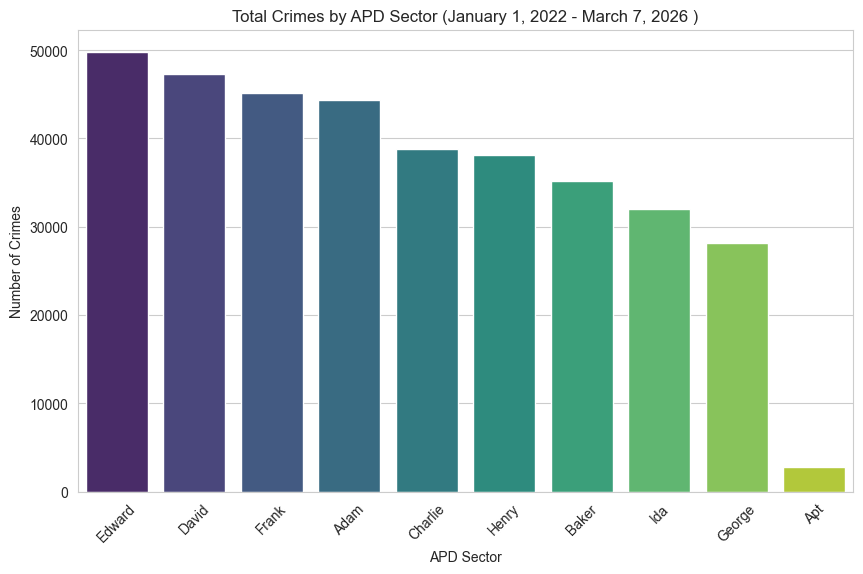

In [6]:
# visualization
plt.figure()

sns.barplot(
    x = sector_counts.index,
    y = sector_counts.values,
    palette = "viridis")

plt.title("Total Crimes by APD Sector (January 1, 2022 - March 7, 2026 )")
plt.xlabel("APD Sector")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)

plt.show()

Edward and David sectors experience the highest volume of crime incidents, while George and Apt report significantly fewer incidents

## 2. Crime trends over time
Is crime increasing or decreasing from Jan 2022 to roughly start of March 2026?

In [7]:
yearly_crime = crime_df.groupby("year").size()

yearly_crime

year
2022    87467
2023    86468
2024    85712
2025    88059
2026    13955
dtype: int64

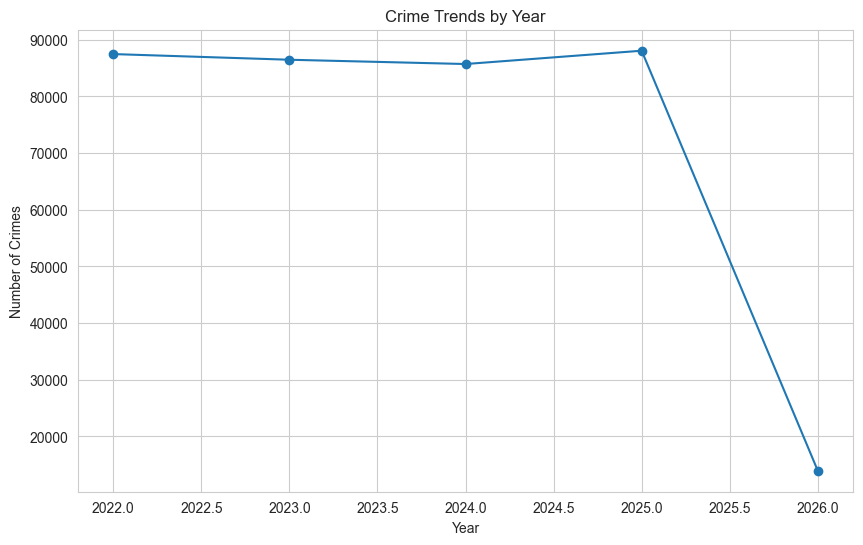

In [8]:
# visualization
yearly_crime.plot(
    kind="line",
    marker="o")

plt.title("Crime Trends by Year")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")

plt.show()

Crime incidents appear relatively stable across the years, with minor fluctuations that may reflect reporting changes or population changes. The newest (max) date in this data is March 7, 2026.

## 3. Crime patterns by hour
When during the day does crime occur most often?

In [9]:
hourly_crime = crime_df.groupby("hour").size()

hourly_crime

hour
0     30966
1     14986
2     14070
3     10988
4      8472
5      6565
6      6736
7      8606
8     11508
9     11605
10    13282
11    13206
12    22001
13    14030
14    14512
15    15996
16    17522
17    18565
18    18890
19    17313
20    17347
21    17552
22    19364
23    17579
dtype: int64

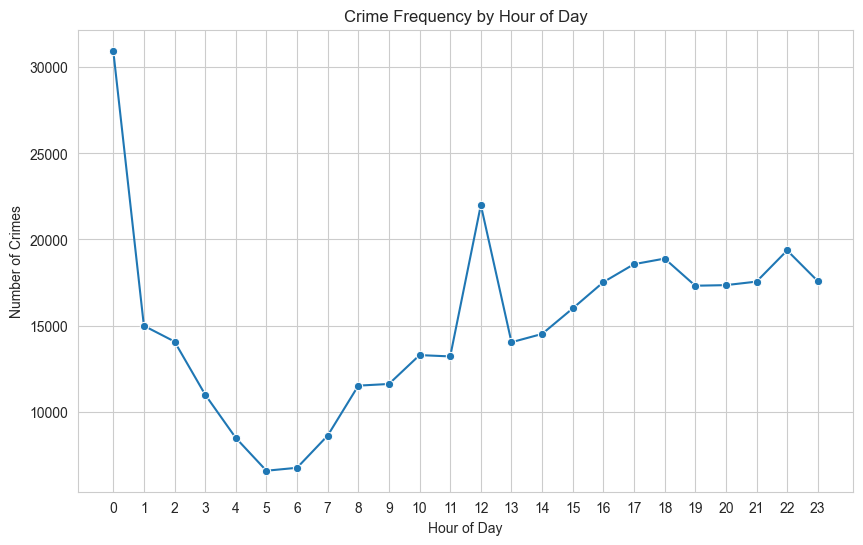

In [10]:
# visualization
plt.figure()

sns.lineplot(
    x = hourly_crime.index,
    y = hourly_crime.values,
    marker="o")

plt.title("Crime Frequency by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Crimes")
plt.xticks(range(0, 24))

plt.show()

Crime tends to increase in the late afternoon and evening hours, peaking significantly at midnight (12 AM).

## 4. Crime patterns by weekday
Which days have the most crime?

In [11]:
weekday_crime = crime_df['weekday'].value_counts()

weekday_crime

weekday
Friday       55337
Saturday     53649
Monday       51652
Sunday       50774
Thursday     50583
Wednesday    50164
Tuesday      49502
Name: count, dtype: int64

In [12]:
# reorder weekdays for better visualization
weekday_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekday_crime = weekday_crime.reindex(weekday_order)

C:\Users\diana\AppData\Local\Temp\ipykernel_2964\683482832.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


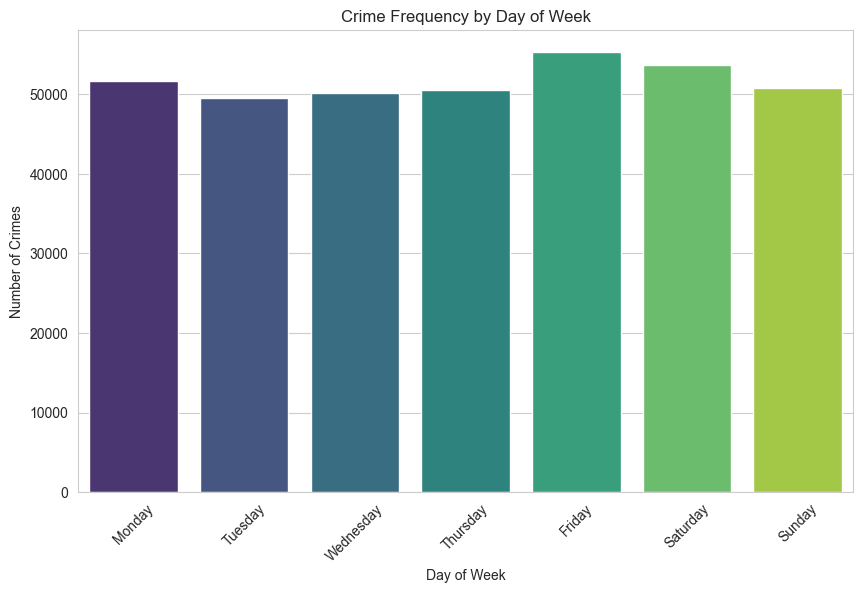

In [13]:
# visualization
sns.barplot(
    x = weekday_crime.index,
    y = weekday_crime.values,
    palette = "viridis")

plt.title("Crime Frequency by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Crimes")
plt.xticks(rotation=45)

plt.show()

Crime frequency tends to increase toward the weekend, with Friday and Saturday showing the most elevated activity during a full week.

## 5. Top crime categories
What crimes dominate Austin?

Note: The dataset crime_df contains two crime classification columns:
    - highest_offense_description (specific offense)
    - category_description (general crime category)

However, category_description contains a large number of missing values (~211k missing inputs). Using this field would exclude a significant portion of incidents from analysis. Therefore, the analysis uses highest_offense_description because it contains nearly complete data and provides more detailed crime information.

In [14]:
top_crimes = crime_df["highest_offense_description"].value_counts().head(10)

C:\Users\diana\AppData\Local\Temp\ipykernel_2964\686750674.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


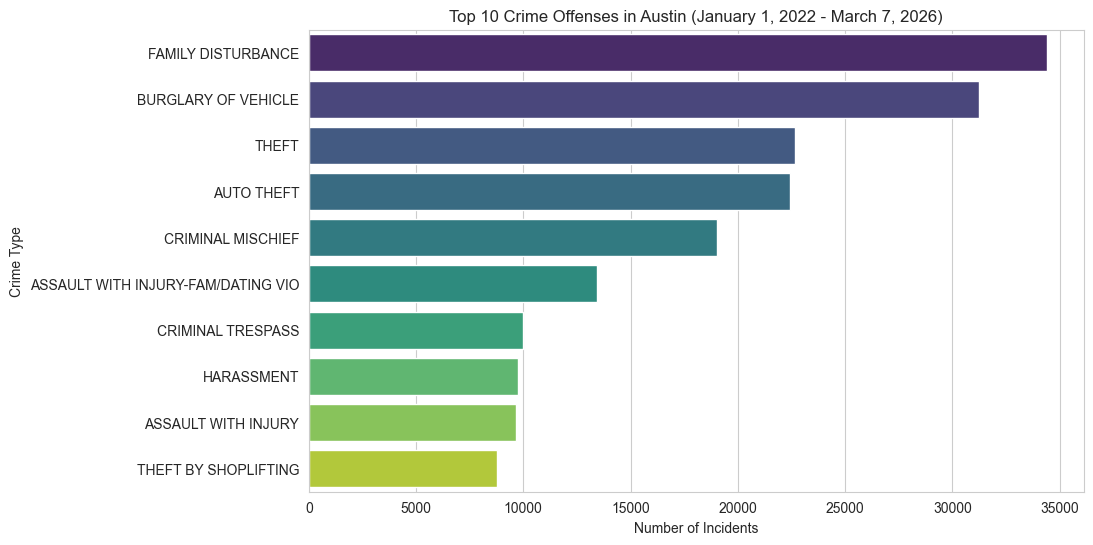

In [15]:
# visualization
plt.figure()

sns.barplot(
    x = top_crimes.values,
    y = top_crimes.index,
    palette = "viridis")

plt.title("Top 10 Crime Offenses in Austin (January 1, 2022 - March 7, 2026)")
plt.xlabel("Number of Incidents")
plt.ylabel("Crime Type")

plt.show()

The most common crime offenses in Austin, TX include family disturbance, burglarly of vehicle, and theft.

## 6. Crime category by sector
Where is crime happening the most in APD sectors?
- help show volume
- highlight high activity sectors

In [16]:
sector_crime_matrix = pd.crosstab(
    crime_df["sector_name_clean"],
    crime_df["highest_offense_description"]
    )

sector_crime_matrix

highest_offense_description,"ABANDONING OR ENDANGERING CHILD, ELDERLY, DISABLED",ABUSE OF 911,ABUSE OF CORPSE,ABUSE OF OFFICIAL CAPACITY,AGG ASLT ENHANC STRANGL/SUFFOC,AGG ASLT STRANGLE/SUFFOCATE,AGG ASLT W/MOTOR VEH FAM/DAT V,AGG ASSAULT,AGG ASSAULT BY PUBLIC SERVANT,AGG ASSAULT ON PEACE OFFICER,...,VIOL STATE LAW - OTHER,VIOL STATE MASSAGE REGULATIONS,VIOL STAY AWAY ORDER,VIOL TEMP EX PARTE ORDER,VOCO - ALCOHOL CONSUMPTION,VOCO SOLICITATION PROHIBIT,VOYEURISM-PEEPING TOM (CHILD ABUSE),VOYEURISM-PEEPING TOM (SEX CRIMES),WARRANT ARREST NON TRAFFIC,WEAPON VIOL - OTHER
sector_name_clean,,,,,,,,,,,,,,,,,,,,,
Adam,14,25,0,0,17,301,8,291,0,5,...,43,0,4,7,1,0,1,0,35,1
Apt,0,0,0,0,0,1,0,5,0,0,...,3,0,0,0,0,0,0,0,37,1
Baker,6,18,0,0,6,144,1,205,0,1,...,24,0,1,3,0,0,0,6,51,0
Charlie,22,11,0,0,18,337,7,577,0,6,...,59,0,2,7,1,1,1,1,70,1
David,25,9,1,0,15,233,5,502,1,1,...,32,1,3,16,1,0,0,0,60,1
Edward,33,54,2,0,37,500,4,913,0,2,...,46,0,0,7,0,2,0,1,44,1
Frank,31,24,0,0,42,446,6,560,0,7,...,40,0,1,16,0,0,0,1,46,1
George,5,11,0,0,4,83,1,380,0,4,...,43,0,10,0,19,0,1,0,85,1
Henry,24,15,0,1,30,375,8,561,0,2,...,37,0,0,10,0,0,0,1,45,1


The dataset has too many categories to visualize. I'll keep the top 15 to reduce noise and improve readibility of the heatmap.

In [17]:
top_categories = crime_df["highest_offense_description"].value_counts().head(15).index

filtered_matrix = pd.crosstab(
    crime_df["sector_name_clean"],
    crime_df["highest_offense_description"]
    )[top_categories]

# sort columns by importance
filtered_matrix = filtered_matrix[
    filtered_matrix.sum().sort_values(ascending=False).index
    ]

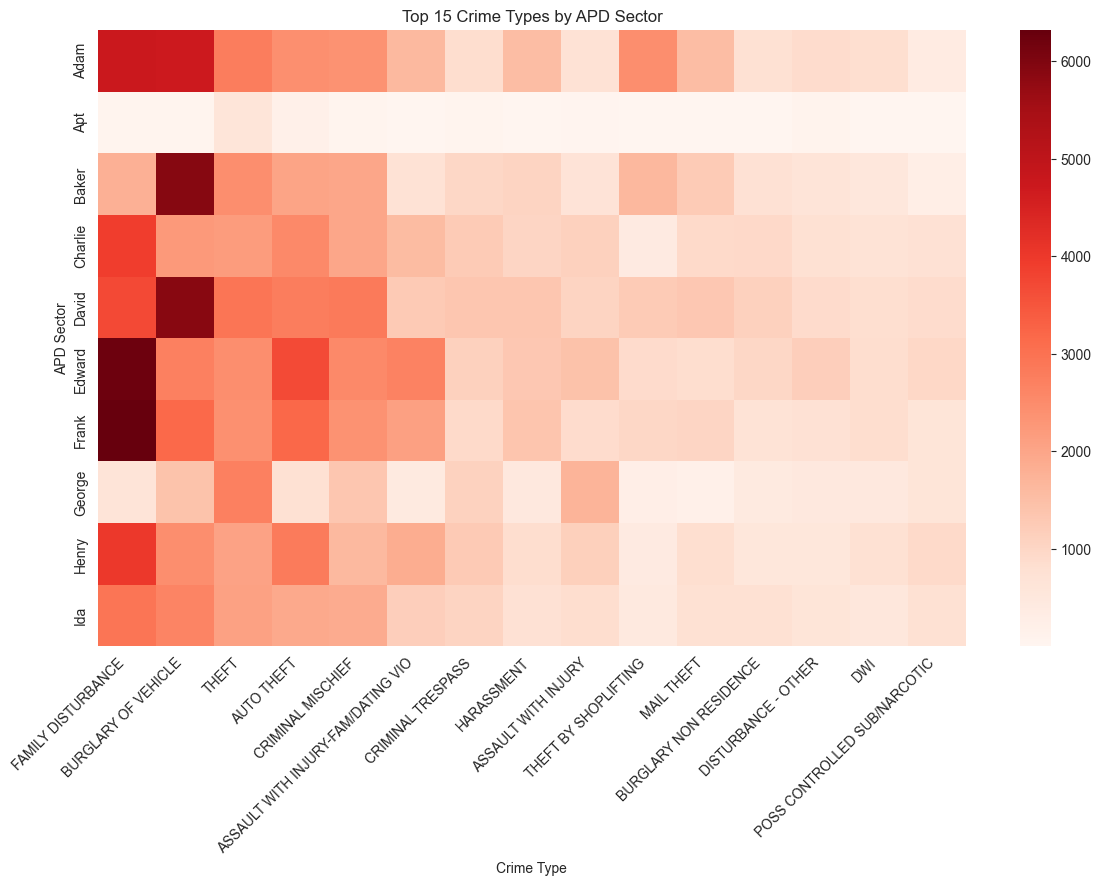

In [18]:
# Visualization - raw counts heatmap
plt.figure(figsize=(14, 8))

sns.heatmap(
    filtered_matrix,
    cmap="Reds"
)

plt.title("Top 15 Crime Types by APD Sector")
plt.xlabel("Crime Type")
plt.ylabel("APD Sector")
plt.xticks(rotation=45, ha="right")

plt.show()

#### Normalize the Top Crime Sector Data
What type of crime is common in each sector?
- convert raw counts to proportions per sector
- remove bias from sector size to allow fair comparison between sectors
- reveal differences in behavior if possible

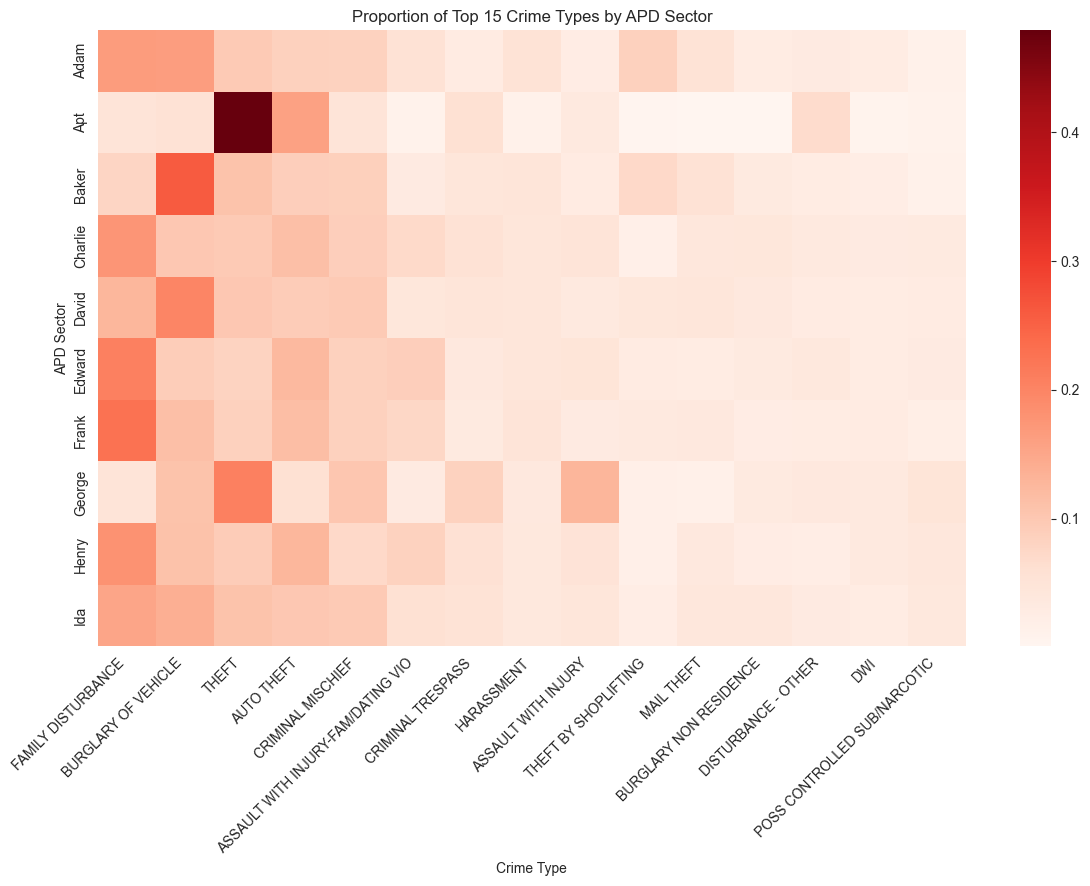

In [19]:
normalized_matrix = filtered_matrix.div(filtered_matrix.sum(axis=1), axis=0)

# Visualization
plt.figure(figsize=(14, 8))

sns.heatmap(
    normalized_matrix, 
    cmap="Reds")

plt.title("Proportion of Top 15 Crime Types by APD Sector")
plt.xticks(rotation=45, ha="right")
plt.xlabel("Crime Type")
plt.ylabel("APD Sector")

plt.show()

The raw counts heatmap shows that certain sectors (e.g., Baker, David, Edward, and Frank) experience higher crime volume.
However, the normalized heatmap reveals that the distribution of crime types is relatively consistent across sectors, while the top 3 offenses still remain true across all sectors. 
Some sectors (e.g., Apt) exhibit slight variation, indicating localized crime patterns that are not visible when looking at raw counts alone.

## Key insights summary

1.  Crime Distribution
Certain sectors (e.g., Edward and David) consistently show higher crime volume.

2. Crime Trends Over Time (Temporal Patterns)
Crime incidents appear relatively stable across Jan 01, 2022 to Mar 07, 2026.

3. Time of Day
Crime increases in the late afternoon and evening hours, and significantly peaks at midnight (12 AM or 00:00 hours).

4. Weekly Trends
Crime increases toward the weekend, with Friday and Saturday showing higher activity.

5. Crime Types
The majority of incidences are family disturbance, burglarly of vehicles, and theft.

6. Sector Differences
Normalized analysis shows that while crime volume differs, the distribution of crime types is relatively similar across sectors, with some localized variation.